# Non-Linear

## import packages


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Read datas


In [3]:
data = pd.read_csv('china_gdp.csv')
data

,Year,Value
0,1960,5.918412e+10
1,1961,4.955705e+10
2,1962,4.668518e+10
3,1963,5.009730e+10
4,1964,5.906225e+10
5,1965,6.970915e+10
6,1966,7.587943e+10
7,1967,7.205703e+10
8,1968,6.999350e+10
9,1969,7.871882e+10


## Visualize Datas


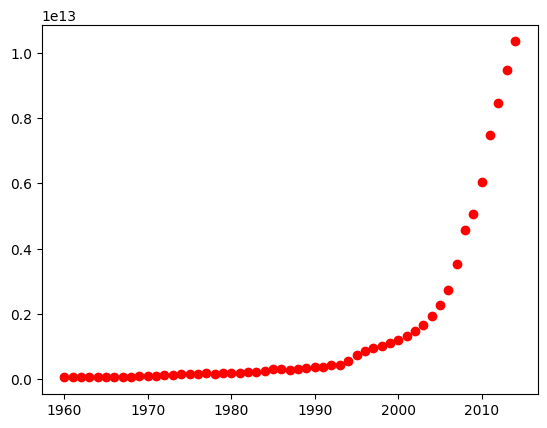

In [43]:
x_data, y_data = data['Year'].values, data['Value'].values
plt.scatter(x_data ,y_data, color='red')

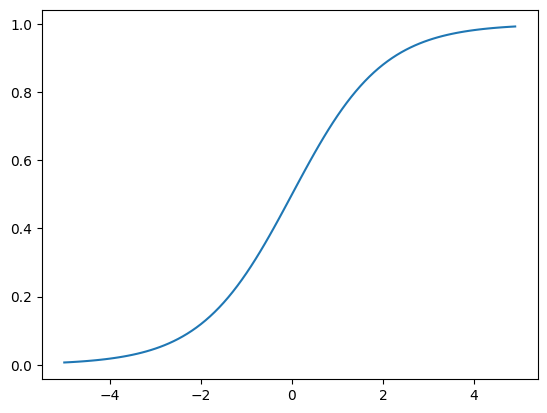

In [44]:
x = np.arange(-5, 5, 0.1)
y = 1 / (1 + np.exp(-x))
plt.plot(x, y)

## modeling

In [49]:
def sigmoid(x, Beta_1, Beta_2):
     y = 1 / (1 + np.exp(-Beta_1*(x-Beta_2)))
     return y

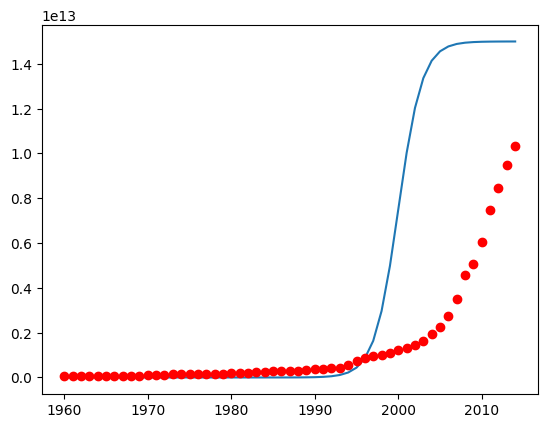

In [55]:
beta_1 = 0.70
beta_2 = 2000
y_pred = sigmoid(x_data, beta_1 , beta_2)

plt.plot(x_data, y_pred*15000000000000)
plt.plot(x_data, y_data, 'ro')

## Normalizing Data


In [58]:
xdata = x_data/max(x_data)
ydata = y_data/max(y_data)
xdata, ydata

(array([0.97318769, 0.97368421, 0.97418073, 0.97467726, 0.97517378,
        0.97567031, 0.97616683, 0.97666336, 0.97715988, 0.97765641,
        0.97815293, 0.97864945, 0.97914598, 0.9796425 , 0.98013903,
        0.98063555, 0.98113208, 0.9816286 , 0.98212512, 0.98262165,
        0.98311817, 0.9836147 , 0.98411122, 0.98460775, 0.98510427,
        0.98560079, 0.98609732, 0.98659384, 0.98709037, 0.98758689,
        0.98808342, 0.98857994, 0.98907646, 0.98957299, 0.99006951,
        0.99056604, 0.99106256, 0.99155909, 0.99205561, 0.99255214,
        0.99304866, 0.99354518, 0.99404171, 0.99453823, 0.99503476,
        0.99553128, 0.99602781, 0.99652433, 0.99702085, 0.99751738,
        0.9980139 , 0.99851043, 0.99900695, 0.99950348, 1.        ]),
 array([0.0057156 , 0.00478589, 0.00450854, 0.00483806, 0.00570384,
        0.00673204, 0.00732793, 0.00695878, 0.0067595 , 0.00760213,
        0.00883705, 0.00951846, 0.01083164, 0.01320831, 0.01373801,
        0.01556399, 0.01464318, 0.01664431, 0.

## Find best betas 

In [63]:
from scipy.optimize import curve_fit
popt, pcov = curve_fit(sigmoid, xdata, ydata)
print(f'beta1: {popt[0]}\nbeta2: {pcov[0]}')

beta1: 690.4517105515218
beta2: [ 1.52271496e+03 -2.88118967e-04]


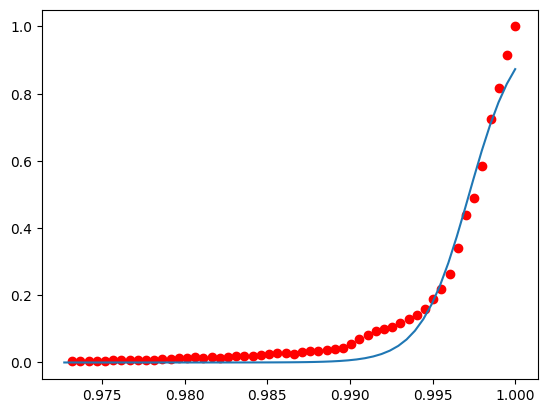

In [69]:
x = np.linspace(1960, 2015, 55)
x = x/max(x)
y = sigmoid(x, *popt)
plt.plot(xdata, ydata, 'ro')
plt.plot(x,y)